# Assignment 4: Data Analytics I
**Objective:** Create a Linear Regression Model using Python to predict home prices using the Boston Housing Dataset.

Dataset Source: [Boston House Prices on Kaggle](https://www.kaggle.com/datasets/vikrishnan/boston-house-prices)

In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
# Load the dataset (Fixed path for Colab)
df = pd.read_csv("/content/BostonHousing.csv")

# Fix the 'NaN' error by dropping missing values before splitting
df = df.dropna()

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7


In [3]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [4]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
5    28.7
Name: MEDV, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

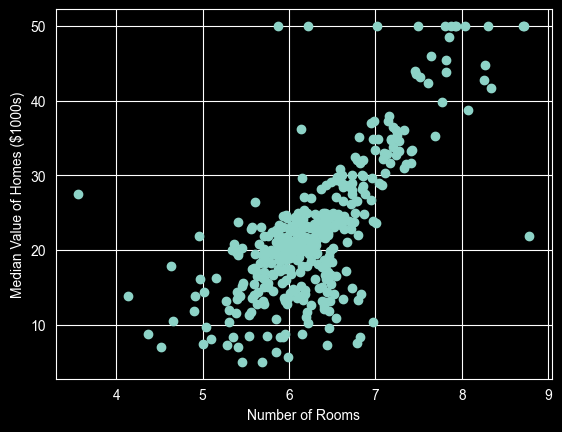

In [6]:
import matplotlib.pyplot as plt

a = df['RM']
b = df['MEDV']

plt.scatter(a, b)
plt.xlabel('Number of Rooms')
plt.ylabel('Median Value of Homes ($1000s)')
plt.show()

In [7]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [8]:
X_train.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
print(mse)

31.454047664950963


In [12]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.627084994167318


In [13]:
print(y_pred)

[29.22850199 17.5037472  21.80803847 30.4942528  18.50265527 34.7432311
 22.07369779 30.7541295  33.52029866 14.82910783 22.14507214 41.26427356
 22.51242483 16.87300668 19.0023074  20.77110711 17.26921288 15.48568273
 22.69482862 14.12652975 18.19319969 20.48292217 17.04235173 29.66737037
 26.09718411 16.06132841 27.09746911 31.45656662 22.64238912 27.06681913
 41.10181897 18.21320236 23.062681   17.41202659 17.39546606 21.076803
 22.38598488 21.66963934 22.9118984  20.80249561 27.70046219 34.60121409
 22.25931447 30.83868791 35.33229137 19.76393425 24.99195034 10.39133132
 19.75538217 25.31114768 21.55934818 25.89776968 14.23212614 18.66822307
 18.34126683 24.31756905 43.40891373 22.87668508 15.3452895  23.17268086
 21.11796307 21.4821572  14.66508216 28.92300146 -3.71655126 32.60224615
 16.81628299 31.90077457 24.78013157 20.11600672 31.55246209 32.35712749
 18.87519084 19.5714957  19.26577986 35.60775919 19.34796049 28.48982534
 16.32963606]
